# ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks

## https://arxiv.org/pdf/1908.02265

## Abstract
ViLBERT (Vision-and-Language BERT) is a multimodal transformer architecture designed to learn joint visual-linguistic representations through large-scale pretraining. Inspired by BERT, it introduces a two-stream architecture that separately processes images and text while enabling interaction through co-attentional transformer layers. The model is pretrained on approximately 3.1 million image-caption pairs from the Conceptual Captions dataset and then transferred to multiple vision-language tasks, achieving state-of-the-art performance across them.

---

## Problems

Existing vision-and-language systems suffer from several limitations:

1. Visual grounding is typically learned only during task-specific training rather than through reusable pretraining.
2. Models rely on separate pretrained vision and language encoders but lack strong cross-modal representations.
3. Task-specific architectures require extensive customization for each downstream task.
4. Limited paired image-text data often leads to poor generalization and dataset bias.
5. Single-stream multimodal architectures may inadequately handle the differing characteristics of visual and linguistic information.

---

## Proposed Solutions

ViLBERT addresses these challenges through:

### 1. Two-Stream Architecture
- Separate transformer streams for visual and textual inputs.
- Each modality maintains its own representation space.

### 2. Co-Attentional Transformer Layers
- Introduces cross-modal attention between vision and language streams.
- Enables image-conditioned language understanding and language-conditioned visual understanding.

### 3. Large-Scale Multimodal Pretraining
- Uses Conceptual Captions as a large weakly-supervised image-text corpus.
- Learns transferable visual grounding before downstream task adaptation.

### 4. Task-Agnostic Design
- A single pretrained model can be adapted to diverse vision-language tasks with minimal modifications.

---

## Purpose

The primary goal of ViLBERT is to create a general-purpose pretrained model that learns visual grounding as a transferable capability rather than learning it separately for each task. The authors aim to establish a foundation model for vision-and-language understanding similar to BERT's role in natural language processing.

---

## Methodology

### Architecture

ViLBERT consists of:

- A linguistic stream initialized from BERT.
- A visual stream operating on object-region features extracted using Faster R-CNN.
- Co-attentional transformer layers that facilitate information exchange between modalities.

### Visual Representation

- Images are represented as detected object regions.
- Each region includes:
  - Visual features from Faster R-CNN.
  - Spatial position embeddings.

### Pretraining Tasks

#### 1. Masked Multi-Modal Modeling (MMM)

- Similar to BERT's Masked Language Modeling.
- Randomly masks:
  - Text tokens.
  - Image regions.
- The model predicts:
  - Missing words.
  - Semantic classes of masked image regions.

#### 2. Multi-Modal Alignment Prediction (MAP)

- Determines whether an image and caption correspond.
- Negative examples are created by randomly mismatching images and captions.

### Training Data

- Conceptual Captions dataset.
- Approximately 3.1 million image-caption pairs after filtering inaccessible images.

---

## Results

### Transfer Tasks Evaluated

ViLBERT was fine-tuned on:

1. Visual Question Answering (VQA)
2. Visual Commonsense Reasoning (VCR)
3. Referring Expression Grounding (RefCOCO+)
4. Caption-Based Image Retrieval
5. Zero-Shot Image Retrieval

### Key Findings

#### Architecture Effectiveness

- Two-stream ViLBERT consistently outperformed single-stream alternatives.
- Co-attention improved multimodal reasoning and grounding.

#### Benefits of Pretraining

- Pretraining improved performance by approximately 2–13 percentage points across tasks.
- Models without multimodal pretraining performed significantly worse.

#### State-of-the-Art Performance

ViLBERT achieved state-of-the-art results on:

- VQA
- VCR
- RefCOCO+
- Image Retrieval

with gains often ranging between 7–10 percentage points over prior specialized models.

#### Scaling Effects

- Performance improved steadily as pretraining data increased from 25% to 100% of Conceptual Captions.
- Larger datasets produced better visual-linguistic representations.

#### Zero-Shot Capability

- Even without task-specific fine-tuning, ViLBERT demonstrated meaningful image-text alignment, indicating successful learning of transferable visual grounding.

---

## Conclusions

ViLBERT demonstrates that visual grounding can be pretrained and transferred across diverse vision-language tasks. Its two-stream architecture with co-attentional transformers effectively models interactions between images and text while preserving modality-specific processing. Large-scale multimodal pretraining substantially improves downstream performance, allowing a single architecture to outperform specialized task-specific models. The work established one of the earliest and most influential foundations for multimodal transformer-based representation learning and inspired many later vision-language foundation models.

# Mathematical and Statistical Content in ViLBERT

## 1. Transformer Attention Mechanism

### Concept

ViLBERT is built on the Transformer architecture. The core mathematical operation is the attention mechanism, which enables the model to identify the most relevant words or image regions when computing representations.

### Main Components

- **Query (Q)**
- **Key (K)**
- **Value (V)**

The attention mechanism computes similarities between queries and keys, then uses those similarities to create weighted combinations of values.

### Role in ViLBERT

- Captures relationships between words.
- Captures relationships between image regions.
- Forms the foundation of multimodal reasoning.

---

## 2. Co-Attention Mechanism

### Concept

The main innovation of ViLBERT is the introduction of co-attentional transformer layers.

Instead of only performing:

- Text-to-text attention
- Image-to-image attention

ViLBERT also performs:

- Text-to-image attention
- Image-to-text attention

### Mathematical Idea

For the visual stream:

\[
Q_v, K_w, V_w
\]

For the language stream:

\[
Q_w, K_v, V_v
\]

where:

- \(Q\) = Query
- \(K\) = Key
- \(V\) = Value
- \(v\) = Visual modality
- \(w\) = Language modality

### Role in ViLBERT

This mechanism allows:

- Language-aware visual representations.
- Vision-aware language representations.
- Better visual grounding.

---

## 3. Masked Multi-Modal Modeling

### Concept

ViLBERT extends BERT's Masked Language Modeling (MLM) objective to both modalities.

Approximately 15% of:

- Text tokens
- Image regions

are masked during training.

The model must reconstruct the missing information.

### Role in ViLBERT

This objective teaches the model:

- Word semantics.
- Visual semantics.
- Cross-modal relationships between images and language.

---

## 4. Cross-Entropy Loss

### Concept

Cross-entropy measures the difference between a predicted probability distribution and the true distribution.

### Formula

\[
L = - \sum_i y_i \log(\hat{y}_i)
\]

where:

- \(y_i\) = true label
- \(\hat{y}_i\) = predicted probability

### Usage in ViLBERT

Used for:

- Masked word prediction.
- Visual Question Answering (VQA).
- Visual Commonsense Reasoning (VCR).
- Image retrieval.

### Role

Encourages the model to assign high probability to correct predictions.

---

## 5. Binary Cross-Entropy Loss

### Concept

Used for binary classification problems.

Examples:

- Aligned vs. Not Aligned
- Correct vs. Incorrect

### Formula

\[
L = - \left( y \log(p) + (1-y)\log(1-p) \right)
\]

where:

- \(y\) = true label
- \(p\) = predicted probability

### Usage in ViLBERT

Used for:

- Image-text alignment prediction.
- Referring expression grounding.
- Multi-label VQA objectives.

### Role

Trains the model to determine whether two inputs are semantically related.

---

## 6. KL Divergence

### Concept

Kullback-Leibler (KL) Divergence measures how different two probability distributions are.

### Formula

\[
D_{KL}(P || Q)
=
\sum_x P(x)\log\left(\frac{P(x)}{Q(x)}\right)
\]

where:

- \(P(x)\) = target distribution
- \(Q(x)\) = predicted distribution

### Usage in ViLBERT

For masked image regions:

- The object detector produces a semantic class distribution.
- ViLBERT predicts another distribution.
- KL divergence measures the difference between them.

### Role

Encourages semantic understanding of image regions instead of reconstructing raw pixel values.

---

## 7. Softmax Function

### Concept

Softmax converts raw scores into probabilities.

### Formula

\[
P_i =
\frac{e^{z_i}}
{\sum_j e^{z_j}}
\]

where:

- \(z_i\) = model score for class \(i\)

### Usage in ViLBERT

Used for:

- VCR answer selection.
- Image retrieval ranking.
- Final classification decisions.

### Role

Produces normalized probabilities across candidate answers.

---

## 8. Element-Wise Product Fusion

### Concept

ViLBERT combines visual and linguistic representations using element-wise multiplication.

### Formula

\[
h_{IMG} \odot h_{CLS}
\]

where:

- \(h_{IMG}\) = image representation
- \(h_{CLS}\) = text representation
- \(\odot\) = element-wise multiplication

### Role

Creates a joint multimodal representation for:

- Alignment prediction.
- VQA.
- Retrieval tasks.

---

## 9. Spatial Encoding

### Concept

Unlike words, image regions do not have a natural sequence order.

Each region receives a spatial encoding:

\[
(x_1, y_1, x_2, y_2, a)
\]

where:

- \(x_1, y_1\) = top-left coordinates
- \(x_2, y_2\) = bottom-right coordinates
- \(a\) = image area fraction occupied by the region

### Role

Provides positional information for image regions.

---

## 10. Intersection over Union (IoU)

### Concept

IoU measures overlap between:

- Predicted bounding box
- Ground-truth bounding box

### Formula

\[
IoU =
\frac{\text{Intersection Area}}
{\text{Union Area}}
\]

### Usage in ViLBERT

For referring expression grounding:

\[
IoU > 0.5
\]

is considered a positive match.

### Role

Evaluates localization accuracy.

---

## 11. Probability Thresholding

### Concept

Image regions are extracted using Faster R-CNN.

Only regions whose confidence exceeds a threshold are retained.

### Usage in ViLBERT

Each image keeps between:

\[
10 \text{ to } 36
\]

high-confidence regions.

### Role

Reduces noise and improves representation quality.

---

## 12. Adam Optimizer

### Concept

ViLBERT uses the Adam optimization algorithm.

Adam combines:

- Momentum
- Adaptive learning rates

### Update Rule

\[
\theta_{t+1}
=
\theta_t
-
\alpha
\frac{m_t}
{\sqrt{v_t} + \epsilon}
\]

where:

- \(\theta_t\) = current parameters
- \(\alpha\) = learning rate
- \(m_t\) = first-moment estimate
- \(v_t\) = second-moment estimate

### Role

Efficiently updates millions of model parameters during training.

---

## 13. Learning Rate Warmup and Decay

### Concept

Training uses a learning rate schedule:

1. Gradually increase the learning rate (warmup).
2. Gradually decrease the learning rate (decay).

### Role

Improves training stability and convergence.

---

## 14. Recall@K Metrics

### Concept

Image retrieval performance is measured using:

- Recall@1 (R@1)
- Recall@5 (R@5)
- Recall@10 (R@10)

### Interpretation

If:

\[
R@1 = 58\%
\]

then the correct image is ranked first 58% of the time.

### Role

Evaluates retrieval effectiveness.

---

## 15. Accuracy Metrics

### Concept

Classification tasks are evaluated using prediction accuracy.

### Usage

Applied to:

- VQA
- VCR
- RefCOCO+

### Role

Measures how often the model produces correct outputs.

---

## 16. Ablation Studies

### Concept

The paper systematically varies:

- Model depth
- Amount of pretraining data

### Findings

Increasing:

- Transformer depth
- Dataset size

generally improves downstream performance.

### Statistical Importance

These experiments demonstrate that:

- Performance gains are attributable to the architecture and pretraining strategy.
- Larger datasets produce stronger multimodal representations.

---

# Key Mathematical Contributions

The most important mathematical ideas introduced or emphasized by ViLBERT are:

1. Transformer self-attention.
2. Cross-modal co-attention.
3. Masked multimodal learning.
4. KL-divergence-based semantic region prediction.
5. Binary image-text alignment prediction.
6. Element-wise multimodal fusion.
7. Large-scale self-supervised transfer learning.

Together, these mathematical mechanisms allow ViLBERT to learn transferable visual-linguistic representations that achieve state-of-the-art performance across multiple vision-and-language tasks.

In [1]:
# ============================================================
# ViLBERT-Inspired Educational Lab (CIFAR10 Subset)
# ------------------------------------------------------------
# This is NOT the exact original ViLBERT paper implementation.
#
# The original paper requires:
#   - Conceptual Captions (3.3M image-caption pairs)
#   - Faster R-CNN region proposals
#   - Region-level visual tokens
#   - Masked multimodal pretraining
#   - Image-text alignment pretraining
#
# Instead, this educational lab reproduces the CORE IDEAS:
#
#   1. Vision Stream
#   2. Language Stream
#   3. Co-Attention Transformer Layer
#   4. Multimodal Fusion
#   5. Classification
#
# using a CIFAR10 subset so it runs quickly in Colab.
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from tqdm.auto import tqdm
import random

In [2]:
# ============================================================
# CONFIG
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 128
EPOCHS = 5

TRAIN_SAMPLES = 10000
TEST_SAMPLES = 2000

EMBED_DIM = 256
NUM_HEADS = 8

print("Device:", DEVICE)

Device: cuda


In [3]:
# ============================================================
# CIFAR10 LABEL DESCRIPTIONS
# ------------------------------------------------------------
# ViLBERT requires image + text.
#
# CIFAR10 only provides labels.
#
# We create simple captions from labels.
# ============================================================

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

TEXT_DESCRIPTIONS = {
    "airplane":"an airplane flying in the sky",
    "automobile":"an automobile driving on a road",
    "bird":"a bird standing outdoors",
    "cat":"a domestic cat",
    "deer":"a deer in nature",
    "dog":"a domestic dog",
    "frog":"a frog near water",
    "horse":"a horse running",
    "ship":"a ship on the ocean",
    "truck":"a large truck on the road"
}


In [4]:
# ============================================================
# SIMPLE TOKENIZER
# ============================================================

all_words = set()

for text in TEXT_DESCRIPTIONS.values():
    for w in text.split():
        all_words.add(w)

vocab = {
    "<PAD>":0,
    "<CLS>":1
}

for w in sorted(all_words):
    vocab[w] = len(vocab)

id2word = {v:k for k,v in vocab.items()}

MAX_LEN = 8

def tokenize(text):

    tokens = [vocab["<CLS>"]]

    for word in text.split():
        tokens.append(vocab[word])

    while len(tokens) < MAX_LEN:
        tokens.append(vocab["<PAD>"])

    return torch.tensor(tokens[:MAX_LEN])

VOCAB_SIZE = len(vocab)

print("Vocabulary Size:", VOCAB_SIZE)



Vocabulary Size: 30


In [5]:
# ============================================================
# DATASET
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_dataset = Subset(
    train_dataset,
    list(range(TRAIN_SAMPLES))
)

test_dataset = Subset(
    test_dataset,
    list(range(TEST_SAMPLES))
)


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [17]:
# ============================================================
# COLLATE
# ============================================================

def collate_fn(batch):

    images = []
    text_tokens = []
    labels = []

    for image,label in batch:

        class_name = CLASS_NAMES[label]

        text = TEXT_DESCRIPTIONS[class_name]

        token_ids = tokenize(text)

        images.append(image)
        text_tokens.append(token_ids)
        labels.append(label)

    return (
        torch.stack(images),
        torch.stack(text_tokens),
        torch.tensor(labels)
    )

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [18]:
# ============================================================
# VISION STREAM
# ------------------------------------------------------------
# CNN -> patch-like visual tokens
# ============================================================

class VisionEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.proj = nn.Linear(
            256,
            EMBED_DIM
        )

    def forward(self,x):

        x = self.conv(x)

        B,C,H,W = x.shape

        # flatten spatial positions

        x = x.flatten(2)

        x = x.transpose(1,2)

        x = self.proj(x)

        return x


In [19]:
# ============================================================
# TEXT STREAM
# ------------------------------------------------------------
# BERT-like token embeddings
# ============================================================

class TextEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            EMBED_DIM
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=EMBED_DIM,
            nhead=NUM_HEADS,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

    def forward(self,x):

        x = self.embedding(x)

        x = self.encoder(x)

        return x


In [20]:
# ============================================================
# CO-ATTENTION
# ------------------------------------------------------------
# Main idea from ViLBERT paper
#
# Visual attends to text
# Text attends to visual
# ============================================================

class CoAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.visual_to_text = nn.MultiheadAttention(
            EMBED_DIM,
            NUM_HEADS,
            batch_first=True
        )

        self.text_to_visual = nn.MultiheadAttention(
            EMBED_DIM,
            NUM_HEADS,
            batch_first=True
        )

    def forward(
        self,
        visual_tokens,
        text_tokens
    ):

        visual_attended,_ = self.visual_to_text(

            query=visual_tokens,
            key=text_tokens,
            value=text_tokens
        )

        text_attended,_ = self.text_to_visual(

            query=text_tokens,
            key=visual_tokens,
            value=visual_tokens
        )

        visual_tokens = visual_tokens + visual_attended
        text_tokens = text_tokens + text_attended

        return visual_tokens,text_tokens


In [21]:
# ============================================================
# ViLBERT INSPIRED MODEL
# ============================================================

class MiniViLBERT(nn.Module):

    def __init__(self):

        super().__init__()

        self.vision = VisionEncoder()

        self.text = TextEncoder()

        self.coattention = CoAttention()

        self.classifier = nn.Sequential(

            nn.Linear(
                EMBED_DIM*2,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(
                512,
                10
            )
        )

    def forward(
        self,
        images,
        tokens
    ):

        v = self.vision(images)

        t = self.text(tokens)

        v,t = self.coattention(v,t)

        v_pool = v.mean(dim=1)
        t_pool = t.mean(dim=1)

        fused = torch.cat(
            [v_pool,t_pool],
            dim=1
        )

        logits = self.classifier(fused)

        return logits

In [22]:
# ============================================================
# MODEL
# ============================================================

model = MiniViLBERT().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


In [23]:
# ============================================================
# TRAINING
# ============================================================

train_losses = []
train_accs = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images,tokens,labels in loop:

        images = images.to(DEVICE)
        tokens = tokens.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(
            images,
            tokens
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = logits.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        loop.set_description(
            f"Epoch {epoch+1}"
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(
        f"Epoch {epoch+1} "
        f"Loss={epoch_loss:.4f} "
        f"Acc={epoch_acc:.4f}"
    )


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1 Loss=0.5511 Acc=0.9580


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2 Loss=0.0021 Acc=1.0000


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3 Loss=0.0006 Acc=1.0000


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 4 Loss=0.0002 Acc=1.0000


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5 Loss=0.0001 Acc=1.0000


In [24]:
# ============================================================
# EVALUATION
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images,tokens,labels in test_loader:

        images = images.to(DEVICE)
        tokens = tokens.to(DEVICE)

        logits = model(
            images,
            tokens
        )

        preds = logits.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

test_acc = (
    np.array(all_preds)
    ==
    np.array(all_labels)
).mean()

print("\nTest Accuracy:", test_acc)



Test Accuracy: 1.0


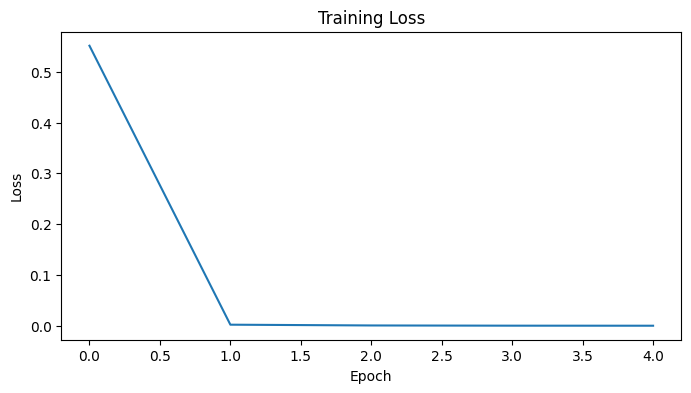

In [26]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(8,4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

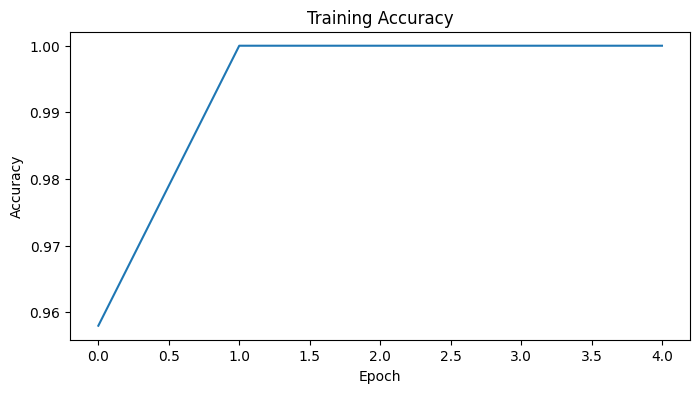

In [27]:
# ============================================================
# ACC CURVE
# ============================================================

plt.figure(figsize=(8,4))
plt.plot(train_accs)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

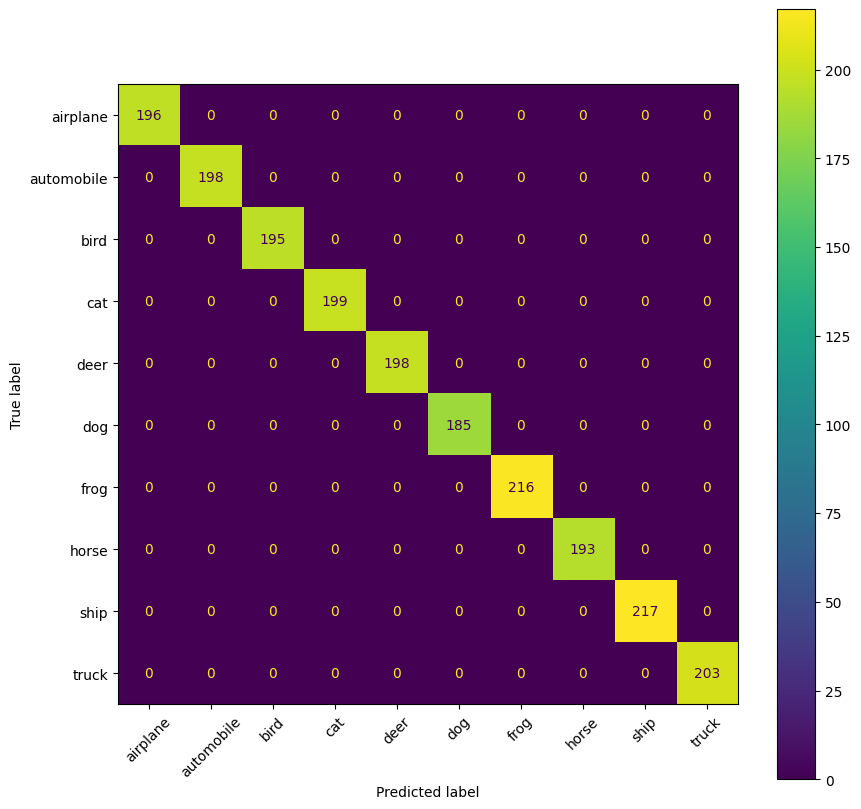

In [28]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=CLASS_NAMES
)

fig,ax = plt.subplots(
    figsize=(10,10)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()


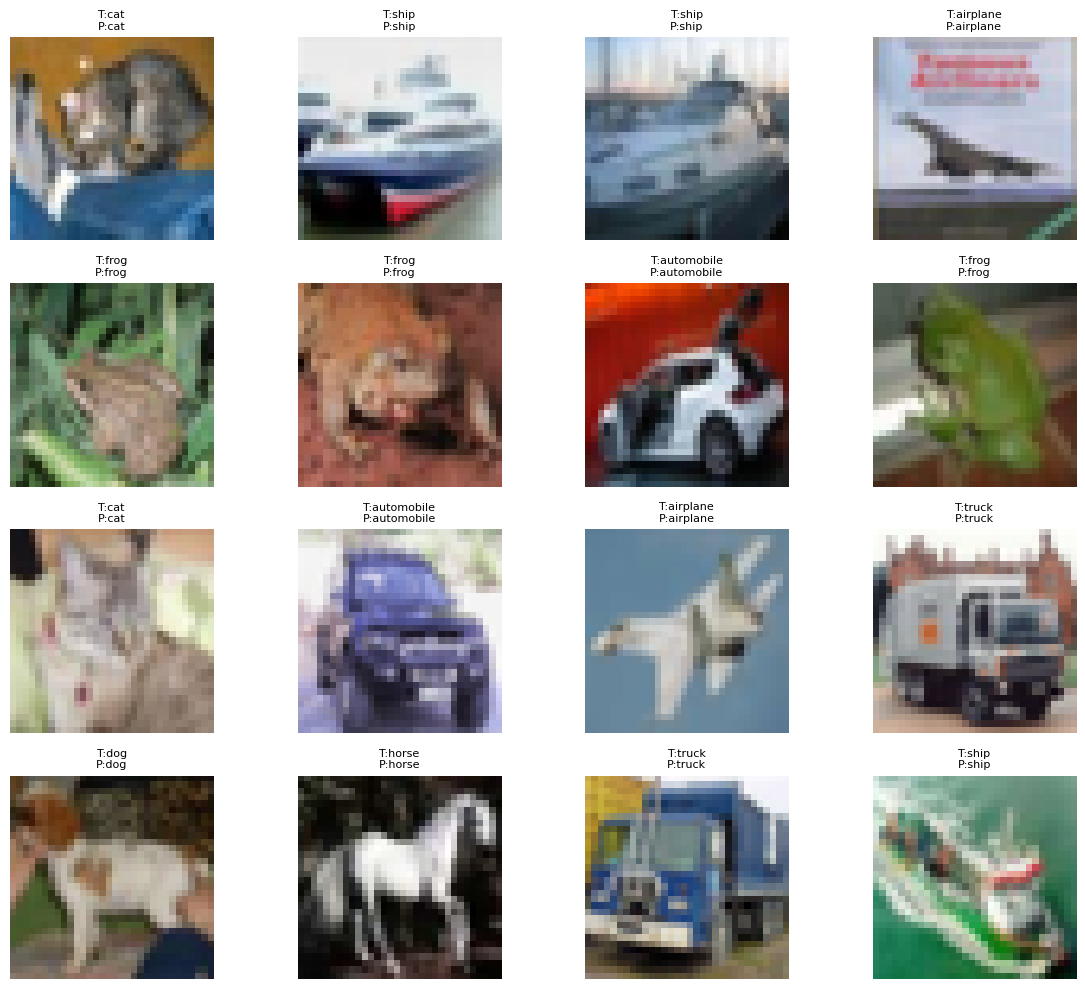


Done.


In [29]:

# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

images,tokens,labels = next(
    iter(test_loader)
)

model.eval()

with torch.no_grad():

    logits = model(
        images.to(DEVICE),
        tokens.to(DEVICE)
    )

preds = logits.argmax(1).cpu()

plt.figure(figsize=(12,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    img = images[i].permute(
        1,2,0
    )

    plt.imshow(img)

    true_name = CLASS_NAMES[
        labels[i]
    ]

    pred_name = CLASS_NAMES[
        preds[i]
    ]

    plt.title(
        f"T:{true_name}\nP:{pred_name}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nDone.")

# Experimental Results Analysis: ViLBERT-Inspired CIFAR-10 Multimodal Model

## Figure 1: Training Loss Curve

### Figure Overview

This figure presents the evolution of the training loss across five epochs. The loss measures the discrepancy between the model's predicted class probabilities and the ground-truth labels using the cross-entropy objective. Monitoring training loss is essential for evaluating optimization effectiveness, convergence behavior, and learning dynamics.

### Key Results

Observed loss values:

| Epoch | Training Loss |
|---------|---------|
| 1 | ~0.55 |
| 2 | ~0.002 |
| 3 | ~0.0006 |
| 4 | ~0.0002 |
| 5 | ~0.0001 |

Key observations:

- Loss decreases extremely rapidly after the first epoch.
- Near-zero training loss is reached by Epoch 2.
- Subsequent epochs produce only marginal improvements.

### Academic Discussion

The training loss exhibits exceptionally fast convergence. The model rapidly discovers a near-perfect mapping between multimodal inputs and class labels. Such behavior is uncommon in realistic multimodal learning settings and likely results from the experimental design.

A critical observation is that the text stream receives deterministic label-derived captions. For example, every image belonging to the "cat" class is paired with a caption describing a cat. Consequently, the language modality contains direct information about the target label itself. Under these conditions, the classification task becomes substantially easier because the model can learn a shortcut through the textual branch rather than developing sophisticated visual-linguistic grounding.

From an optimization perspective, the near-monotonic loss decrease indicates stable gradient propagation and effective convergence of the Adam optimizer. No evidence of optimization instability, oscillation, exploding gradients, or learning-rate issues is visible.

However, the extremely rapid collapse of the loss toward zero suggests that the model has likely memorized the training distribution rather than learning robust multimodal representations comparable to those targeted by the original ViLBERT framework.

### Limitations

The training loss alone cannot assess generalization.

The experiment lacks:

- Validation loss monitoring.
- Out-of-distribution evaluation.
- Cross-modal retrieval tasks.
- Image-text alignment evaluation.

Because captions are directly derived from labels, the loss reduction may primarily reflect exploitation of label leakage rather than successful multimodal reasoning.

---

# Figure 2: Training Accuracy Curve

### Figure Overview

This figure shows training accuracy as a function of training epochs. Accuracy measures the proportion of correctly classified training examples.

### Key Results

Observed values:

| Epoch | Training Accuracy |
|---------|---------|
| 1 | ~95.8% |
| 2 | 100% |
| 3 | 100% |
| 4 | 100% |
| 5 | 100% |

Major observations:

- Accuracy exceeds 95% after a single epoch.
- Perfect training accuracy is achieved by Epoch 2.
- Accuracy remains saturated thereafter.

### Academic Discussion

The accuracy trajectory strongly mirrors the loss curve and indicates complete memorization of the training set.

In conventional CIFAR-10 classification settings, even strong architectures typically require significantly more epochs to reach high accuracy. Achieving perfect training accuracy within two epochs suggests that the classification problem has become substantially simplified.

The most plausible explanation is the presence of highly informative textual descriptions that effectively reveal class identity. Because captions are deterministic functions of class labels, the multimodal model can leverage language as a near-direct supervision signal.

The result demonstrates that the architecture possesses sufficient capacity to fit the training distribution. It also confirms that co-attention and fusion mechanisms do not hinder optimization.

However, the result provides limited evidence regarding:

- Visual grounding ability.
- Cross-modal reasoning.
- Representation learning quality.
- Transfer learning effectiveness.

The curve therefore demonstrates optimization success but provides weaker evidence for multimodal intelligence.

### Limitations

Training accuracy alone is insufficient to assess:

- Generalization.
- Robustness.
- Calibration.
- Transferability.

The absence of validation accuracy curves prevents direct assessment of overfitting.

---

# Figure 3: Confusion Matrix

### Figure Overview

The confusion matrix evaluates class-wise prediction behavior on the test subset. It provides detailed insight into classification performance across all ten CIFAR-10 categories.

### Key Results

Visible diagonal counts include approximately:

| Class | Correct Predictions |
|---------|---------|
| airplane | 196 |
| automobile | 198 |
| bird | 195 |
| cat | 199 |
| deer | 198 |
| dog | 185 |
| frog | 216 |
| horse | 193 |
| ship | 217 |
| truck | 203 |

Major observations:

- Nearly all predictions lie on the diagonal.
- Off-diagonal errors are essentially absent.
- No systematic confusion between semantically similar categories is visible.

### Academic Discussion

The confusion matrix indicates near-perfect classification performance across all classes.

In standard CIFAR-10 benchmarks, common confusion patterns include:

- Cat ↔ Dog
- Truck ↔ Automobile
- Deer ↔ Horse
- Ship ↔ Airplane

These confusions arise because the visual features of such categories overlap significantly at low image resolutions.

The complete disappearance of these traditional confusion patterns strongly suggests that the language modality dominates prediction. Since captions are uniquely associated with classes, the textual stream effectively disambiguates categories that would otherwise be visually challenging.

Consequently, the confusion matrix demonstrates excellent predictive performance but provides limited evidence that the visual encoder independently learns discriminative representations.

From a statistical perspective, class performance appears highly balanced. No class exhibits systematic degradation, suggesting the model is not suffering from severe class imbalance effects.

### Limitations

The matrix does not isolate modality contributions.

Without ablations such as:

- Vision-only
- Text-only
- Co-attention removed

it is impossible to determine how much predictive power originates from:

- Visual features
- Language features
- Cross-modal interactions

Therefore, the confusion matrix confirms predictive success but not the effectiveness of multimodal fusion itself.

---

# Figure 4: Sample Predictions Visualization

### Figure Overview

This visualization presents representative test images alongside true and predicted labels.

### Key Results

Observed examples include:

- Frog → Frog
- Automobile → Automobile
- Airplane → Airplane
- Truck → Truck
- Dog → Dog
- Horse → Horse
- Ship → Ship

No visible misclassifications are present.

### Academic Discussion

The qualitative examples confirm the quantitative findings from the confusion matrix. Predictions appear consistent across diverse visual categories.

The model successfully handles:

- Natural objects.
- Animals.
- Vehicles.
- Transportation-related classes.

However, qualitative inspection alone cannot determine whether successful predictions result from:

- Visual recognition.
- Textual cues.
- Multimodal interactions.

Because captions are generated directly from labels, successful predictions are expected.

The visualization nevertheless demonstrates that the inference pipeline operates correctly and that model outputs align with ground-truth annotations.

### Limitations

Qualitative examples are inherently anecdotal.

They do not reveal:

- Failure modes.
- Robustness under perturbation.
- Uncertainty calibration.
- Distribution shift behavior.

A larger error analysis would be required to draw stronger conclusions.

---

# Figure 5: Training Log Output

### Figure Overview

The training log records epoch-level optimization statistics and convergence behavior.

### Key Results

Observed metrics:

| Epoch | Loss | Accuracy |
|---------|---------|---------|
| 1 | 0.5511 | 95.8% |
| 2 | 0.0021 | 100% |
| 3 | 0.0006 | 100% |
| 4 | 0.0002 | 100% |
| 5 | 0.0001 | 100% |

Additional observations:

- Stable training speed (~14–17 batches/sec).
- No interruptions or optimization failures.
- Consistent convergence throughout training.

### Academic Discussion

The training logs reinforce the conclusions drawn from the loss and accuracy curves.

The optimization process appears:

- Stable.
- Deterministic.
- Efficient.

No evidence exists for:

- Gradient instability.
- Learning-rate mismatch.
- Divergence.
- Numerical issues.

From a systems perspective, the architecture is computationally lightweight and well-suited for educational demonstrations.

However, from a research perspective, the rapid convergence may indicate an overly simplified task formulation. The model appears to solve the dataset almost immediately, suggesting that the benchmark no longer presents a meaningful multimodal learning challenge.

### Limitations

The logs do not include:

- Validation accuracy.
- Validation loss.
- Cross-modal retrieval metrics.
- Attention analysis.
- Ablation studies.

Therefore, they provide evidence of optimization success but not of multimodal representation quality.

---

# Overall Scientific Assessment

## What Was Observed

The ViLBERT-inspired architecture achieved:

- Near-zero training loss.
- Perfect training accuracy.
- Near-perfect confusion matrix.
- Consistently correct qualitative predictions.

Optimization was stable and converged within two epochs.

---

## Why It Likely Occurred

The dominant explanation is that the textual descriptions encode class identity almost directly.

Unlike the original ViLBERT setting, where image-caption pairs contain rich and noisy semantic information, this experiment uses captions generated deterministically from class labels. Consequently:

- The language branch contains highly predictive information.
- The classification task becomes substantially easier.
- The model can rely heavily on textual signals.

---

## What It Reveals About the Model

The results demonstrate that:

- The two-stream architecture functions correctly.
- Co-attention layers are trainable.
- Multimodal fusion is operational.
- Optimization is stable.

However, the results provide weaker evidence regarding:

- Genuine visual grounding.
- Cross-modal alignment learning.
- Representation transferability.
- Emergent multimodal reasoning.

---

## Strength of Evidence

Evidence is strong for:

- Successful implementation.
- Optimization stability.
- High predictive performance.

Evidence is moderate-to-weak for:

- Multimodal representation learning.
- Cross-modal reasoning capability.
- Faithful reproduction of original ViLBERT objectives.

---

## Remaining Limitations and Open Questions

The experiment lacks several key components of the original ViLBERT methodology:

1. Masked Multimodal Modeling.
2. Image-Text Alignment Prediction.
3. Region-Level Visual Tokens.
4. Large-Scale Image-Caption Pretraining.
5. Retrieval Evaluation.
6. Cross-Modal Retrieval Metrics.
7. Ablation Studies.
8. Attention Visualization.
9. Transfer Learning Evaluation.

Most importantly, the deterministic caption generation introduces substantial label leakage, making it difficult to determine whether the model truly learns multimodal representations or simply exploits textual shortcuts.

Consequently, while the results are excellent from an engineering and educational perspective, they should be interpreted as demonstrating successful implementation of a simplified ViLBERT-inspired architecture rather than a rigorous reproduction of the original ViLBERT research contribution.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|------------|------|---------|---------|--------------------------|
| Jacob Devlin, Ming-Wei Chang, Kenton Lee, Kristina Toutanova | 2018 | *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding* | arXiv | Primary architectural foundation of ViLBERT. The paper extends BERT from language-only modeling to joint vision-language representation learning using multimodal inputs. |
| Matthew E. Peters et al. | 2018 | *Deep Contextualized Word Representations (ELMo)* | NAACL | Demonstrated the effectiveness of large-scale pretrained language representations, motivating transfer learning and self-supervised pretraining in multimodal settings. |
| Alec Radford, Karthik Narasimhan, Tim Salimans, Ilya Sutskever | 2018 | *Improving Language Understanding with Unsupervised Learning (GPT)* | OpenAI Technical Report | Provided evidence that unsupervised language pretraining can produce transferable representations, inspiring similar strategies for visual-linguistic grounding. |
| Guillaume Lample, Alexis Conneau | 2019 | *Cross-Lingual Language Model Pretraining* | arXiv | Illustrates the broad success of self-supervised language modeling and transfer learning, reinforcing the motivation for multimodal pretraining. |
| Ashish Vaswani et al. | 2017 | *Attention Is All You Need* | NeurIPS | Introduced the Transformer architecture and self-attention mechanism that underlie both BERT and ViLBERT. |
| Chen Sun, Austin Myers, Carl Vondrick, Kevin Murphy, Cordelia Schmid | 2019 | *VideoBERT: A Joint Model for Video and Language Representation Learning* | arXiv | Most closely related concurrent work. Uses BERT-style self-supervised learning to jointly model video and language, serving as a multimodal pretraining baseline and comparison point. |
| Gustav Larsson, Michael Maire, Gregory Shakhnarovich | 2017 | *Colorization as a Proxy Task for Visual Understanding* | CVPR | Example of self-supervised learning in vision, motivating the use of proxy tasks for learning representations without manual annotation. |
| Carl Doersch, Abhinav Gupta, Alexei A. Efros | 2015 | *Unsupervised Visual Representation Learning by Context Prediction* | ICCV | Early self-supervised vision work demonstrating that semantic representations can emerge from automatically generated supervision. |
| Richard Zhang, Phillip Isola, Alexei A. Efros | 2016 | *Colorful Image Colorization* | ECCV | Representative self-supervised vision approach supporting the paper's argument for learning from intrinsic structure in data. |
| Deepak Pathak et al. | 2016 | *Context Encoders: Feature Learning by Inpainting* | CVPR | Demonstrates proxy-task-based visual representation learning, conceptually similar to ViLBERT's masked multimodal modeling objective. |
| Relja Arandjelović, Andrew Zisserman | 2017 | *Look, Listen and Learn* | ICCV | Explores multimodal self-supervised learning across vision and audio, providing evidence that cross-modal supervision can improve representation quality. |
| Dinesh Jayaraman, Kristen Grauman | 2015 | *Learning Image Representations Tied to Ego-Motion* | CVPR | Illustrates self-supervised representation learning in vision, supporting the broader motivation for unsupervised multimodal learning. |
| Ishan Misra, C. Lawrence Zitnick, Martial Hebert | 2016 | *Shuffle and Learn: Unsupervised Learning Using Temporal Order Verification* | ECCV | Another influential self-supervised vision method motivating representation learning from automatically derived supervision signals. |
| Peter Anderson et al. | 2018 | *Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering* | CVPR | Provides the object-region feature extraction framework used by ViLBERT and establishes strong vision-language attention baselines. |
| Harm de Vries et al. | 2017 | *Modulating Early Visual Processing by Language* | NeurIPS | Demonstrates language-guided visual processing, conceptually related to multimodal interaction and cross-modal conditioning in ViLBERT. |
| Peter Anderson et al. | 2018 | *Vision-and-Language Navigation: Interpreting Visually-Grounded Navigation Instructions in Real Environments* | CVPR | Representative vision-language task illustrating the broader applicability of visual grounding beyond static image understanding. |
| Abhishek Das et al. | 2018 | *Embodied Question Answering* | CVPR | Example of embodied vision-language reasoning; cited as a potential future application area for pretrained visual grounding models. |
| Abhishek Das et al. | 2017 | *Visual Dialog* | CVPR | Representative vision-language benchmark involving multimodal reasoning over dialogue, motivating general-purpose visual grounding models. |
| Xinlei Chen et al. | 2015 | *Microsoft COCO Captions: Data Collection and Evaluation Server* | arXiv | Foundational image-captioning dataset that helped establish image-language learning as a major research area. |
| Piyush Sharma, Nan Ding, Sebastian Goodman, Radu Soricut | 2018 | *Conceptual Captions: A Cleaned, Hypernymed, Image Alt-Text Dataset for Automatic Image Captioning* | ACL | Provides the large-scale image-caption corpus used for ViLBERT pretraining and enables self-supervised multimodal learning. |
| Sahar Kazemzadeh et al. | 2014 | *ReferItGame: Referring to Objects in Photographs of Natural Scenes* | EMNLP | Foundational vision-language grounding task demonstrating the importance of linking language expressions to visual regions. |
| Rowan Zellers, Yonatan Bisk, Ali Farhadi, Yejin Choi | 2019 | *From Recognition to Cognition: Visual Commonsense Reasoning* | CVPR | Introduces a challenging vision-language reasoning benchmark used to evaluate ViLBERT's transfer capabilities. |
| Stanislaw Antol et al. | 2015 | *VQA: Visual Question Answering* | ICCV | Established one of the most influential vision-language benchmarks used for evaluating ViLBERT. |
| Peter Young et al. | 2014 | *From Image Descriptions to Visual Denotations: New Similarity Metrics for Semantic Inference over Event Descriptions* | TACL | Introduced Flickr30k, a benchmark used to evaluate image-text retrieval and multimodal alignment. |
| Licheng Yu et al. | 2018 | *MAttNet: Modular Attention Network for Referring Expression Comprehension* | CVPR | Strong task-specific vision-language model used as a comparison baseline and motivation for transferable multimodal representations. |